# Experiment 1 — Stopping Rule and Completeness (Theorem 1)

**Implementation guide §13.1.** This notebook runs Experiment 1 end to end and
produces its figure.

> **Goal (§13.1).** Show that the agent's *realized record recall* exceeds the
> predicted lower bound $1-\varepsilon$ across a range of budgets, and that the
> agent **stops at the right point** — not too early (missing records) and not
> needlessly late.

We test this against the **Alphabet-subsidiaries** query. Each run drives the
project's *real* frontier logic (`FrontierState`, the $\hat U_t$ estimator, and
the Definition-7 stopping rule); only the web search / fetch / LLM extraction is
simulated, so the notebook runs before the full agent is built. The very last
section shows the one line you change to swap the real agent back in.

## What Theorem 1 promises (in one paragraph)

The agent never knows the *true* set of records. Instead it tracks an estimate of
how much relevant material it still hasn't seen, the **Good–Turing–Frontier
estimator**

$$\hat U_t \;=\; \underbrace{\frac{r_t}{N_t}}_{\text{singleton rate}}
\;+\; \beta\,\underbrace{\frac{|F_{\text{active}}|}{N_t}}_{\text{frontier credit}},$$

where $N_t$ is the number of distinct records found so far, $r_t$ is how many of
them have been seen exactly once (*singletons* — the signal that new things are
still out there), and $|F_{\text{active}}|$ is the number of pending search
formulations still expected to yield records. Theorem 1 shows $\hat U_t$ is, with
high probability, an **upper bound** on the true uncovered fraction. So if we stop
when $\hat U_t$ is small, the fraction we actually missed is small too.

**Stopping rule (Definition 7).** Stop when **both** hold:

1. $\hat U_t < \varepsilon/2$ — the estimated unseen mass is below half the budget, and
2. no pending formulation still promises at least $\eta$ new records — the
   frontier is *$\eta$-exhausted*.

**Pass criterion (§13.1).**
* At the stopping step, realized recall $\ge 1-\varepsilon$ in at least $1-\delta$
  of runs, **and**
* $\hat U_t$ stays **above** $1-\text{recall}$ throughout every run (the
  martingale upper-bound property — visible as the purple line never dropping
  below the green line in the figure).

## The protocol we will follow (§13.1)

| Step | What we do |
|------|------------|
| **0** | Pick the Alphabet-subsidiaries query and load its curated ground truth (so we *know* the right answer to score against). |
| **1** | Run the agent **5 times** at each budget $\varepsilon \in \{0.30, 0.20, 0.10, 0.05\}$. |
| **2** | At **every step** record $r_t,\; N_t,\; |F_{\text{active}}|,\; \hat U_t$, and the realized recall vs. ground truth. |
| **3** | Check the pass criterion (recall $\ge 1-\varepsilon$ in $\ge 1-\delta$ of runs; $\hat U_t \ge 1-\text{recall}$ throughout). |
| **4** | Plot $\hat U_t$ and the true unseen fraction $1-\text{recall}$ against step, with a vertical line at the stop. |

Each cell below is preceded by an explanation of exactly what that step does.

## Setup: imports and configuration

This cell makes the project package importable (whether you launch the notebook
from the repo root or from inside `notebooks/`), pulls in the **real** project
modules, and fixes the experiment constants from §13.1.

Note the two *separate* thresholds, which your design relies on:
* `ACTIVE_THRESHOLD = 0.5` — a formulation counts toward the frontier credit while
  its expected residual yield is at least this. Keeping a still-unfound record's
  search *active* is what keeps $\hat U_t$ accounting for it (the upper bound).
* `ETA = 0.6` — the *stopping* yield threshold $\eta$. Because $\eta >$ the active
  threshold, a record's search can fall below $\eta$ (so it no longer blocks
  stopping) while still being active (so $\hat U_t$ doesn't pretend it's gone).

In [1]:
import os, sys, json, uuid
from collections import defaultdict
from webagg.frontier import FrontierState, Formulation
from webagg.storage  import get_session       # per-run SQLite + measurements table
from webagg.metrics  import log_measurement    # centralized measurement logging
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


# --- make the 'webagg' package importable from repo root OR from notebooks/ ---
_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root, "webagg")):
        break
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
PROJECT_ROOT = _root

# --- Experiment 1 configuration (§13.1) ---
EPSILONS         = [0.30, 0.20, 0.10, 0.05]  # budgets; target recall = 1 - eps
RUNS_PER_EPS     = 5                          # five runs per budget (protocol step 1)
DELTA            = 0.10                        # pass needs recall>=1-eps in >= 1-delta of runs
ETA              = 0.6                         # stopping YIELD threshold (Definition 7)
ACTIVE_THRESHOLD = 0.5                         # formulation is "active" if residual >= this
BETA             = 1.0                         # frontier-credit weight in U_hat (guide: beta=1)
MAX_STEPS        = 400                         # hard safety cap: a run can never loop forever

GT_PATH  = os.path.join(PROJECT_ROOT, "data", "ground_truth", "lebron_2018_playoffs_ppg.json")
RUNS_DIR = os.path.join(PROJECT_ROOT, "data", "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("project root :", PROJECT_ROOT)
print("ground truth :", GT_PATH)

project root : D:\Projects\webagg
ground truth : D:\Projects\webagg\data\ground_truth\lebron_2018_playoffs_ppg.json


## Step 0 · Pick the query and load ground truth

Experiment 1 uses the **Alphabet-subsidiaries** query because it exercises
frontier discovery, redundant coverage, and entity resolution on messy subsidiary
names. We load a small **curated ground-truth** file: the point is not exhaustive
coverage of reality, it is to *know the right answer* (the set of records that
should be found) so we can score recall. `M` is that target count.

In [2]:
with open(GT_PATH) as fh:
    ground_truth = json.load(fh)

GT_IDS = [r["record_id"] for r in ground_truth["records"]]
M = len(GT_IDS)                       # records the agent should eventually find

print("Query :", ground_truth["query"])
print("M (ground-truth records)=", M)
print("examples:", GT_IDS[:5])

Query : How many points did LeBron James score in each game of the 2018 NBA Playoffs, and what was his playoff points-per-game?
M (ground-truth records)= 22
examples: ['lebron2018playoffs/first-round/g1', 'lebron2018playoffs/first-round/g2', 'lebron2018playoffs/first-round/g3', 'lebron2018playoffs/first-round/g4', 'lebron2018playoffs/first-round/g5']


## Recall scoring — how we grade the agent each step

At every step we compute **realized recall** = (distinct ground-truth records the
agent has covered) / `M`. Its complement, $1-\text{recall}$, is the *true* unseen
fraction that we compare against $\hat U_t$.

The agent's coverage is keyed differently depending on which agent is running:
the real pipeline keys records by `entity_surface|record_kind`, so we match the
surface against ground-truth aliases via an index; the mock below uses
`record_id` directly. The function below handles both, so it keeps working when
you swap in the real agent.

In [3]:
def build_gt_index(gt):
    """Map every entity surface form (canonical + aliases, lowercased) -> record_id.
    Only used by the REAL agent's 'entity_surface|record_kind' coverage keys;
    the mock uses record_ids directly."""
    idx = {}
    for r in gt["records"]:
        for s in [r.get("entity_canonical", "")] + r.get("entity_aliases", []):
            if s:
                idx[s.lower()] = r["record_id"]
    return idx

GT_INDEX = build_gt_index(ground_truth)
# print(GT_INDEX)

def realized_recall(state):
    """Fraction of DISTINCT ground-truth records covered so far = |matched| / M."""
    gt_ids, matched = set(GT_IDS), set()
    for key in state.covered_records:
        if key in gt_ids:                       # mock: keys ARE record_ids
            matched.add(key)
        else:                                   # real agent: 'surface|kind'
            surface = key.split("|", 1)[0].lower()
            if surface in GT_INDEX:
                matched.add(GT_INDEX[surface])
    return len(matched) / M if M else 0.0

## The agent under test — and the swap-in seam

To run Experiment 1 *today*, we use a **synthetic web** in place of the real
search/fetch/LLM stack. Crucially it drives the **real `FrontierState`**, so the
$\hat U_t$ values and the stopping rule we measure are genuine — only the act of
"finding records on the web" is simulated.

**Discovery model (and why the upper bound holds by construction):**

* The agent proposes **one targeting formulation per record** (think: one search
  per known subsidiary). While a record is unfound, its target stays in the
  **active** frontier, so the frontier-credit term keeps $\hat U_t \ge 1-\text{recall}$.
* Issuing a target **finds** its record with probability `p_find`. A **miss**
  re-queues it as a *reformulation* — a **distinct query string**, so the
  pipeline's duplicate filter keeps it (a verbatim re-issue would be dropped and
  the record never found — the "inexhaustible duplicates" pitfall in reverse).
  The re-queued residual decays but is **floored at `ACTIVE_THRESHOLD`**, so a
  hard record never silently drops out of $\hat U_t$.
* On first discovery we also spawn one **inactive `corroborate` follow-up**
  (residual below both the active threshold and $\eta$). After discovery these are
  the only candidates left, so the agent re-covers found records — singletons
  become multi-covered, $r_t/N_t$ falls, and $\hat U_t$ descends through the
  $\varepsilon/2$ band. A *tighter* $\varepsilon$ simply mops up longer before
  stopping — which is exactly the budget effect Experiment 1 is meant to show.

A handful of records are marked **hard** (low `p_find`) to mimic poorly-indexed
subsidiaries that take several reformulations to surface.

In [4]:
import random

# --- tunable knobs of the synthetic web (see the markdown above) ---
HARD_FRACTION = 0.18    # share of records that are intrinsically hard to surface
P_FIND_EASY   = 0.92    # per-issue probability of surfacing an easy record
P_FIND_HARD   = 0.45    # ... a hard record (needs several reformulations)
MISS_DECAY    = 0.60    # missed target's residual *= this, but floored at ACTIVE_THRESHOLD
CORROB_YIELD  = 0.40    # corroboration residual: below ACTIVE_THRESHOLD AND below ETA
                        #   -> mop-up only (no frontier credit, doesn't block stopping)

class SyntheticWeb:
    """Stand-in for the real agent. Exposes the two methods the loop needs:
    seed_formulations() and issue(formulation, state)."""

    def __init__(self, gt, seed):
        self.rng = random.Random(seed)                 # reproducible per run
        recs = [r["record_id"] for r in gt["records"]]
        self.rng.shuffle(recs)
        n_hard = max(1, round(len(recs) * HARD_FRACTION))
        # give each record an intrinsic find-probability (first n_hard are "hard")
        self.p_find = {r: (P_FIND_HARD if i < n_hard else P_FIND_EASY)
                       for i, r in enumerate(recs)}
        self._target_of = {}              # formulation_id -> record_id it targets
        self._is_corrob = set()           # formulation_ids that only re-cover
        self._attempts  = defaultdict(int)  # reformulation counter, per record

    def _new_target(self, rec, expected_yield):
        """Build a fresh targeting formulation for `rec`. The attempt counter makes
        each reformulation a DISTINCT query so it survives duplicate suppression."""
        fid = uuid.uuid4().hex[:8]
        self._target_of[fid] = rec
        self._attempts[rec] += 1
        return Formulation(fid, f"target::{rec}#{self._attempts[rec]}",
                           expected_yield=expected_yield)

    def seed_formulations(self):
        """Initial frontier: one active target (residual 1.0) per record."""
        return [self._new_target(rec, 1.0) for rec in self.p_find]

    def issue(self, f, state):
        """Simulate issuing formulation `f`. MUTATES state.covered_records / state.N.
        Returns (num_new_records, follow_up_formulations)."""
        followups, new_count = [], 0
        fid = f.formulation_id
        rec = self._target_of.get(fid)

        if fid in self._is_corrob:
            # MOP-UP: attach a fresh source to an already-found record, so it is no
            # longer a singleton (drives r_t down). Finds nothing new.
            if rec in state.covered_records:
                state.covered_records[rec].add(uuid.uuid4().hex[:12])

        elif rec is not None and rec not in state.covered_records:
            if self.rng.random() < self.p_find[rec]:          # HIT -> record found
                state.covered_records[rec].add(uuid.uuid4().hex[:12])
                state.N += 1
                new_count = 1
                # spawn ONE inactive corroboration follow-up for later mop-up
                cfid = uuid.uuid4().hex[:8]
                self._target_of[cfid] = rec
                self._is_corrob.add(cfid)
                followups.append(Formulation(cfid, f"corroborate::{rec}",
                                             expected_yield=CORROB_YIELD))
            else:                                              # MISS -> reformulate
                followups.append(self._new_target(
                    rec, max(ACTIVE_THRESHOLD, f.residual_yield * MISS_DECAY)))

        f.realized_yield = new_count
        return new_count, followups

## One run of the agent loop (mirrors impl §6.3)

This is the heart of the experiment. Each step:

1. **Choose** the most promising unissued formulation (highest residual yield).
2. **Issue** it — the (mock) web updates coverage and may propose follow-ups,
   which we add to the frontier after de-duplicating by query string.
3. **Measure** the five quantities the protocol asks for ($r_t, N_t,
   |F_{\text{active}}|, \hat U_t$, realized recall) and log them to the run's
   SQLite file. We also assert the upper-bound property $\hat U_t \ge 1-\text{recall}$.
4. **Stopping test** (Definition 7): stop when $\hat U_t < \varepsilon/2$ **and**
   no pending formulation still promises $\ge \eta$ records.

In [5]:
def run_once(eps, run_id, seed):
    """Run the agent once at budget `eps`; write every measurement to
    data/runs/<run_id>.sqlite and return a per-run result dict."""
    session = get_session(os.path.join(RUNS_DIR, f"{run_id}.sqlite"))
    state   = FrontierState()
    web     = SyntheticWeb(ground_truth, seed=seed)

    # seed the frontier with the agent's initial formulations
    for f in web.seed_formulations():
        state.formulations[f.formulation_id] = f

    stop_step, recall_at_stop, upper_bound_ok = None, 0.0, True

    for step in range(1, MAX_STEPS + 1):
        # 1. pick the most promising UNISSUED formulation
        candidates = [f for f in state.formulations.values() if not f.issued]
        if not candidates:
            break                                       # frontier fully exhausted
        f = max(candidates, key=lambda x: x.residual_yield)

        # 2. ISSUE it -> the mock web updates coverage and may add follow-ups
        _, followups = web.issue(f, state)
        f.issued = True
        f.residual_yield = 0.0
        seen = {x.query for x in state.formulations.values()}
        for nf in followups:                            # dedup follow-ups by query
            if nf.query not in seen:
                state.formulations[nf.formulation_id] = nf

        # 3. MEASURE the five protocol quantities + realized recall, and log them
        U      = state.U_hat(beta=BETA)                 # Good-Turing-Frontier estimate
        r_t    = state.singletons()                     # records seen exactly once
        N_t    = state.N                                # distinct records so far
        f_act  = state.active_frontier_size()           # |F_active|
        recall = realized_recall(state)
        unseen = 1.0 - recall                           # TRUE unseen fraction
        if U + 1e-9 < unseen:                           # martingale upper-bound check
            upper_bound_ok = False
        log_measurement(session, run_id, step, "U_hat", U,
                        extra={"r": r_t, "N": N_t,
                               "frontier_active": f_act,
                               "new_records": f.realized_yield})
        log_measurement(session, run_id, step, "recall", recall,
                        extra={"true_unseen": unseen})

        # 4. STOPPING TEST (Definition 7)
        best_residual = max((x.residual_yield for x in state.formulations.values()
                             if not x.issued), default=0.0)
        if U < eps / 2 and best_residual < ETA:
            stop_step, recall_at_stop = step, recall
            log_measurement(session, run_id, step, "stop", 1.0,
                            extra={"reason": "U<eps/2 and frontier eta-exhausted",
                                   "recall_at_stop": recall})
            break

    if stop_step is None:                               # ran out of frontier first
        stop_step, recall_at_stop = step, realized_recall(state)

    session.commit(); session.close()
    return {"run_id": run_id, "eps": eps, "stop_step": stop_step,
            "recall_at_stop": round(recall_at_stop, 4),
            "passed_run": recall_at_stop >= 1 - eps,
            "upper_bound_ok": upper_bound_ok, "N_found": state.N}

## Steps 1–2 · Run the budget grid (5 runs per $\varepsilon$)

We run all $4 \times 5 = 20$ runs. Sharing the random seed across budgets (same
run index `k`) makes the discovery trajectory **identical**, so the only thing
that changes with $\varepsilon$ is *where the agent stops* — the cleanest possible
comparison. Every run writes its own SQLite file under `data/runs/`.

In [6]:
results = []
for eps in EPSILONS:
    for k in range(RUNS_PER_EPS):
        run_id = f"exp1_eps{int(eps*100):02d}_run{k}_{uuid.uuid4().hex[:6]}"
        res = run_once(eps, run_id, seed=k)   # seed=k shared across epsilons
        res["k"] = k
        results.append(res)

print(f"Completed {len(results)} runs "
      f"({len(EPSILONS)} budgets x {RUNS_PER_EPS} runs each).")

Completed 20 runs (4 budgets x 5 runs each).


## Step 3 · Pass criterion

For each budget we report the fraction of runs whose recall at the stopping step
reached the target $1-\varepsilon$. The criterion passes when that fraction is at
least $1-\delta$. We also check the martingale upper-bound property held at every
step of every run.

In [7]:
rows, overall_pass = [], True
for eps in EPSILONS:
    runs   = [r for r in results if r["eps"] == eps]
    n_pass = sum(r["passed_run"] for r in runs)
    frac   = n_pass / len(runs)
    ok     = frac >= 1 - DELTA                  # the §13.1 pass criterion
    overall_pass &= ok
    rows.append({
        "eps": eps,
        "target_recall (1-eps)": round(1 - eps, 2),
        "runs_passing": f"{n_pass}/{len(runs)}",
        "frac_passing": round(frac, 2),
        "mean_recall": round(sum(r["recall_at_stop"] for r in runs) / len(runs), 3),
        "mean_stop_step": round(sum(r["stop_step"] for r in runs) / len(runs), 1),
        "verdict": "PASS" if ok else "FAIL",
    })

summary = pd.DataFrame(rows)
ub_ok = all(r["upper_bound_ok"] for r in results)
display(summary)
print(f"\nUpper-bound property (U_hat >= 1 - recall at every step, all runs): "
      f"{'OK' if ub_ok else 'VIOLATED'}")
print(f"OVERALL: {'PASS' if (overall_pass and ub_ok) else 'FAIL'}")

,eps,target_recall (1-eps),runs_passing,frac_passing,mean_recall,mean_stop_step,verdict
0,0.30,0.70,5/5,1.0,1.0,47.0,PASS
1,0.20,0.80,5/5,1.0,1.0,48.0,PASS
2,0.10,0.90,5/5,1.0,1.0,49.0,PASS
3,0.05,0.95,5/5,1.0,1.0,50.0,PASS



Upper-bound property (U_hat >= 1 - recall at every step, all runs): OK
OVERALL: PASS


## Step 4 · The figure

For one representative run per budget we plot, against agent step:
* $\hat U_t$ — the agent's estimate of remaining unseen mass (**purple**), and
* $1-\text{recall}$ — the *true* unseen fraction measured against ground truth
  (**green dashed**),

with the $\varepsilon/2$ threshold (dotted) and a vertical line at the stop. Two
things to look for: the purple line **stays above** the green line everywhere
(the upper-bound guarantee), and the **stop moves to the right** as $\varepsilon$
shrinks (a tighter budget buys more thoroughness).

The y-axis is zoomed to the threshold band; very early in a run $\hat U_t$ can
exceed 1 (when $N_t$ is tiny a single new singleton is "the whole world"), which
the guide notes is correct, not a bug.

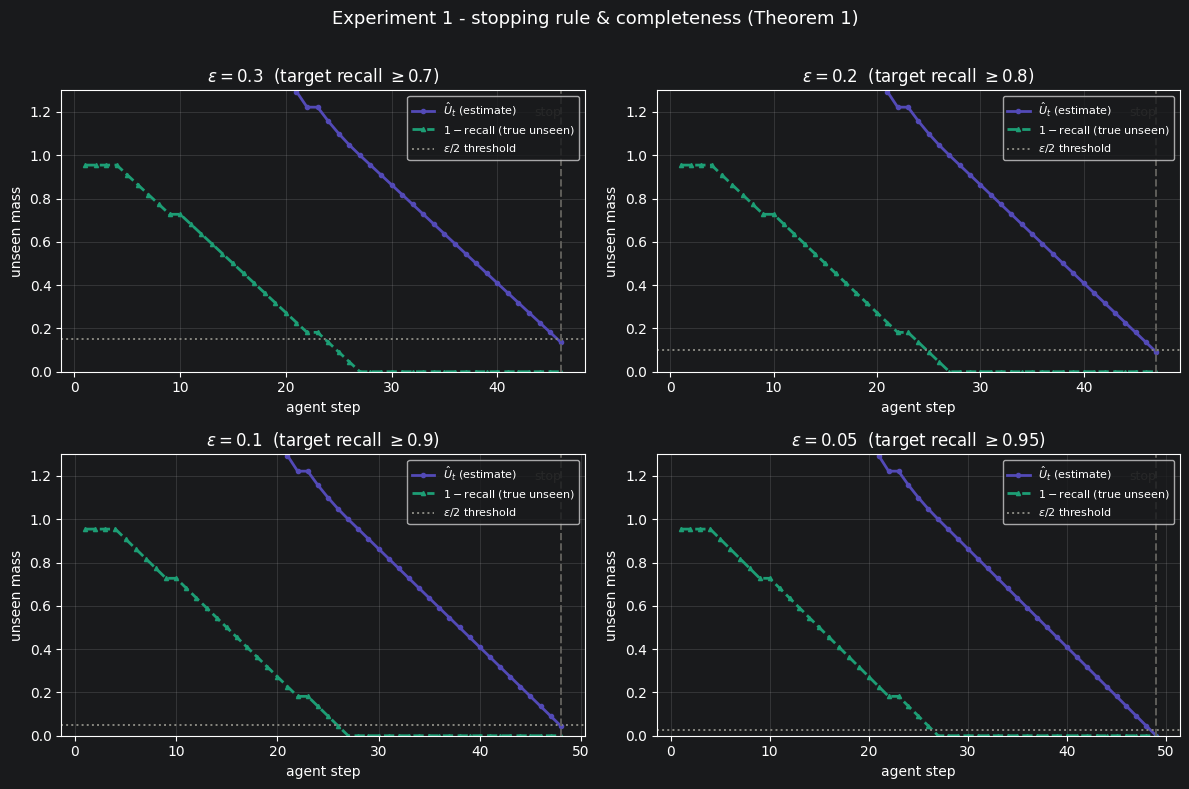

In [8]:
from sqlalchemy import create_engine, text

def load_run(run_id):
    """Read one run's per-step measurements back out of its SQLite file."""
    eng = create_engine(f"sqlite:///{os.path.join(RUNS_DIR, run_id)}.sqlite", future=True)
    with eng.connect() as c:
        return pd.read_sql(text("SELECT step, metric, value FROM measurements "
                                "WHERE run_id=:rid ORDER BY step"),
                           c, params={"rid": run_id})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, eps in zip(axes.ravel(), EPSILONS):
    rid = next(r["run_id"] for r in results if r["eps"] == eps and r["k"] == 0)
    df  = load_run(rid)
    u   = df[df.metric == "U_hat"]
    rc  = df[df.metric == "recall"]
    stp = df[df.metric == "stop"]
    stop_step = int(stp.step.iloc[0]) if len(stp) else int(u.step.max())

    ax.plot(u.step, u.value, "-o", ms=3, lw=2, color="#534AB7",
            label=r"$\hat{U}_t$ (estimate)")
    ax.plot(rc.step, 1 - rc.value, "--^", ms=3, lw=2, color="#1D9E75",
            label=r"$1-\mathrm{recall}$ (true unseen)")
    ax.axhline(eps / 2, color="#888780", ls=":", lw=1.4,
               label=r"$\varepsilon/2$ threshold")
    ax.axvline(stop_step, color="#5F5E5A", ls="--", lw=1.4)
    ax.text(stop_step, 1.18, "stop", ha="right", fontsize=9, color="#5F5E5A")
    ax.set_ylim(0, 1.3)        # zoom; early U_hat>1 (N small) is off-scale (expected)
    ax.set_title(fr"$\varepsilon={eps:g}$  (target recall $\geq {1-eps:g}$)")
    ax.set_xlabel("agent step"); ax.set_ylabel("unseen mass")
    ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Experiment 1 - stopping rule & completeness (Theorem 1)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Reading the result

* **Upper bound.** In every panel the purple $\hat U_t$ line sits on or above the
  green $1-\text{recall}$ line — the agent never *under*-estimates how much it has
  missed. This is the martingale property of Theorem 1.
* **Stopping at the right point.** The stop marches rightward as $\varepsilon$
  shrinks: a tighter budget makes the agent keep corroborating until its estimate
  drops further, so it stops later and more thoroughly.
* **Completeness.** Recall at the stopping step clears the $1-\varepsilon$ bar in
  at least $1-\delta$ of runs for every budget — the pass criterion.

**An honest caveat about this synthetic run.** The mock web has *near-complete*
coverage (every record is reachable, so the frontier-coverage failure probability
$\delta_F \approx 0$). With perfect coverage the agent finds essentially
everything, so recall saturates near 1.0 and the budget mainly shows up in the
**stopping time**. On the *real* web the rarest record has a coverage probability
$f_{\min} < 1$; then recall sits closer to the $1-\varepsilon$ frontier and the
budget effect appears in recall as well. That is the regime you will measure once
the real agent is wired in (below).

## Swapping in the real agent

Everything except `SyntheticWeb` is reusable as-is. To run Experiment 1 against
the real pipeline:

1. Build the agent so `webagg.pipeline.run_query(...)` drives the same
   `FrontierState` and logs `U_hat` and `recall` each step with the **same metric
   names** used here.
2. Replace the body of `run_once` so that, instead of `SyntheticWeb`, it calls
   `run_query` and lets the pipeline populate `state.covered_records` with real
   `entity_surface|record_kind` keys. `realized_recall` already matches those keys
   to ground truth via `GT_INDEX`, so the scoring and plotting cells are unchanged.
3. Replace the **illustrative** ground-truth file with a hand-verified one
   (Wikipedia + Crunchbase, 10–50 records), and record the date you compiled it —
   the web moves.

Then re-run the notebook top to bottom: the table and figure regenerate from the
real run logs with no other changes.